Problem statement -> Take an input from user of a 3D matrix and then apply convolution with input kernel of square matrix and add bias term and pass that through ReLU and then apply 2D max pooling .

In [ ]:
import numpy as np
import torch

For Manual Input

```
"""
(c,h,w) = (int(input("Enter the no. of channels ")),int(input("Height of image ")),int(input("Width of image ")))

import numpy as np

matrix_3D = np.empty((c,h,w))

for i in range(c):
    print(f"Enter the numbers for channel {i+1} ")
    for j in range(h):
        print(f"Enter the numbers for row {j+1} ")
        for k in range(w):
            matrix_3D[i][j][k] = float(input())

size = int(input("Enter the size of square kernel and then input the data values for kernel  "))

kernel = np.empty((c,size,size))

for i in range(c):
    print(f"Enter the numbers for channel {i+1} ")
    for j in range(size):
        print(f"Enter the numbers for row {j+1} ")
        for k in range(size):
            kernel[i][j][k] = float(input())
"""
```



# PyTorch's automatic differentiation engine (Autograd) tracks operations by watching PyTorch functions (like +, *, torch.sum, torch.clamp). It cannot track standard Python code like if, max(), or indexing assignments (so any kind of indexing assignment breaks it down) .

torch.clamp avoids manual assignment by operating directly on the entire underlying memory buffer at the C++ level. Instead of dealing with individual elements one by one, it processes the whole tensor in a single, unified mathematical operation and returns a brand-new tensor.

Forward Pass:
[Input Tensor] ---> (torch.clamp function) ---> [Output Tensor]
                                                       │
                                            (Hidden: clamp_backward)
 clamp_backward tag acts as a receipt. It explicitly instructs PyTorch: "During the backward pass, if the input value was greater than 0, let the gradient pass through. If it was less than or equal to 0, block the gradient."

### 🧠 Crucial PyTorch Mechanics: Dicts, Stack, vs. Tensor

When building custom layers with loops, how you store and combine your calculations determines whether backpropagation will work or break.

#### 1. Why Python Dictionaries Work
* **No In-Place Modification:** Assigning a value to a dictionary (`temp_dict[key] = val`) is **not** a PyTorch tensor operation.
* **Passive Pointers:** The dictionary acts as a passive container holding memory pointers to your calculated tensors.
* **Unbroken History:** PyTorch completely ignores the dictionary and focuses entirely on the underlying mathematical transformations, keeping the gradient tracking history (`grad_fn`) on each tensor perfectly alive.

#### 2. `torch.stack()` vs. `torch.tensor()`
* **`torch.stack(list_of_tensors)` (Preserves the Graph):** Acts on a list of tensors and actively recognizes the individual tracking strings ("gradient tape") attached to each item. It braids them together into a new master node (`StackBackward`), keeping the computational graph completely intact for backpropagation.
* **`torch.tensor(list_of_tensors)` (Cuts the Graph):** Acts as a pair of scissors. It looks at the list, copies *only* the raw floating-point numbers, and discards all historical tracking information. It creates a brand-new **leaf tensor** with no connection to your weights, causing training to fail silently.

| Method | Handles Gradients? | Action on Computational Graph | Suitable for Training? |
| :--- | :--- | :--- | :--- |
| **`torch.stack()`** | ✅ Yes | Bundles individual gradient histories together | **Yes (Required here)** |
| **`torch.tensor()`** | ❌ No | Cuts the history; copies raw values only | ❌ No (Weights won't update) |

In [ ]:
class Convolution:
  def __init__(self,matrix_3d,filters,kernel_size,pool_size,stride_pool):
    self.matrix_3D = matrix_3d
    self.c = matrix_3d.shape[0]
    self.h = matrix_3d.shape[1]
    self.w = matrix_3d.shape[2]
    self.filters = filters
    self.size = kernel_size
    self.window_h = pool_size[0]
    self.window_w = pool_size[1]
    self.stride = stride_pool
    self.new_dim_h = int(((self.h - self.size)/1) + 1)
    self.new_dim_w = int(((self.w - self.size)/1) + 1)
    self.final_h = int(np.floor((self.new_dim_h - self.window_h)/self.stride) + 1)
    self.final_w = int(np.floor((self.new_dim_w - self.window_w)/self.stride) + 1)
    self.weights = torch.empty(filters,self.c,kernel_size,kernel_size)
    self.biases = torch.zeros(filters)
    self.linear_weights = torch.empty(filters * self.final_h * self.final_w,2)
    self.linear_biases = torch.zeros(2)

    """This step has to be done only when the gradient tracking is turned off otherwise process of filling with random values will be treated as mathematical step during forward pass , use : with torch.no_grad()."""

    bound = 1/torch.sqrt(torch.tensor(self.c * self.size * self.size))
    torch.nn.init.uniform_(self.weights , -bound, bound) # how actually weights are initialised in torch's conv2d
    bound = 1/torch.sqrt(torch.tensor(self.filters * self.final_h * self.final_w))
    torch.nn.init.uniform_(self.linear_weights,-bound , bound)

  # We will define the filtering

  def convolution(self):

    assert self.size <= self.h and self.size <= self.w

    temp_dict = {}

    for kernel in range(self.filters):

      for i in range(self.c):

        for j in range(self.new_dim_h): # loop is already bounded by new_dim_h and new_dim_w,no need  of explicitly checking j+size <= h or k + size <= w

          for k in range(self.new_dim_w):

            # temp_array[kernel,i,j,k] = torch.sum(self.matrix_3D[ i , j : j + self.size , k : k + self.size ] * self.weights[kernel,i]) --> in place assignment will cause an error during back propagation (solution : store the values to be assigned in a dictionary with it's coordinates kernel,i,j,k as key and then use them to construct a whole new output tensor by stacking layers )

            temp_dict[kernel,i,j,k] = torch.sum(self.matrix_3D[ i , j : j + self.size , k : k + self.size ] * self.weights[kernel,i])

      # Reconstructing the whole tensor by stacking layers

    kernels = []
    for kernel in range(self.filters):

      channel = []

      for i in range(self.c):

        rows = []

        for j in range(self.new_dim_h):

          cols = [temp_dict[kernel,i,j,k] for k in range(self.new_dim_w)]
          rows.append(torch.stack(cols))  # ---> why torch.stack is used can be seen in previous markdown cell

        channel.append(torch.stack(rows))

      kernels.append(torch.sum(torch.stack(channel),axis = 0) + self.biases[kernel])

    output = torch.stack(kernels)

    return output

  """Overwriting a tensor whose gradient tracking is on, using an equal sign -> PyTorch cannot track how that specific number was modified relative to the rest of the tensor. This corrupts the mathematical history needed for backpropagation. PyTorch will immediately throw a RuntimeError stating that a leaf variable cannot be modified in-place. However , we need to track the transformation torch.tensor is going through inside ReLU and avoid in place assignment -> solution is torch.clamp"""

  def ReLU(self,matrix):

    return torch.clamp(matrix,min = 0)

  def MaxPool2D(self,matrix):

    assert self.window_h <= self.new_dim_h and self.window_w <= self.new_dim_w

    pool_dic = {}

    for filters in range(matrix.shape[0]):

      for i,outer in enumerate(range(0,self.new_dim_h,self.stride)):

        if (outer + self.window_h ) <= self.new_dim_h:

          for j,inner in enumerate(range(0,self.new_dim_w,self.stride)):

            if (inner + self.window_w ) <= self.new_dim_w:

              pool_dic[filters,i,j] = torch.max(matrix[filters , outer : outer + self.window_h ,  inner : inner + self.window_w])

            else:

                break
        else:

          break

    kernels = []
    for kernel in range(self.filters):

      rows = []

      for i in range(self.final_h):

        cols = [pool_dic[kernel,i,j] for j in range(self.final_w)]
        rows.append(torch.stack(cols))  # ---> why torch.stack is used can be seen in previous markdown cell

      kernels.append(torch.stack(rows))

    pooled_output = torch.stack(kernels)

    return pooled_output

  def Linear(self,matrix):

    flattened_array = matrix.flatten()

    result = torch.matmul(flattened_array,self.linear_weights) + self.linear_biases

    return result

  def forward(self):

    x = self.convolution()
    x = self.ReLU(x)

    # print("After convolution shape : ",x.shape)

    x = self.MaxPool2D(x)

    # print("Pooled shape : ",x.shape)

    output = self.Linear(x)

    # print("Final shape is : ",output.shape)

    return output

In [ ]:
# Fixed seed setup
torch.manual_seed(42)

# 1 Channel, 3x3 mock image data
case1_image = torch.tensor([[[1.0, 2.0, 3.0],
                         [4.0, 5.0, 6.0],
                         [7.0, 8.0, 9.0]]])

# Instantiate Model
test_unit1 = Convolution(matrix_3d=case1_image, filters=1, kernel_size=2, pool_size=(2,2), stride_pool=1)

# Forward pass
output_1 = test_unit1.forward()

print("\n--- TEST CASE 1 RESULT ---")
print("Output Tensor:", output_1)
print("Is Gradient Track Active?:", output_1.grad_fn is not None)

After convolution shape :  torch.Size([1, 2, 2])
Pooled shape :  torch.Size([1, 1, 1])
Final shape is :  torch.Size([2])

--- TEST CASE 1 RESULT ---
Output Tensor: tensor([-1.6648,  1.5332])
Is Gradient Track Active?: False


### Custom Cross-Entropy Loss Derivation

The general formula for Cross-Entropy between a true distribution $p$ and a predicted distribution $q$ is:


$$H(p, q) = -\sum_{i} p_i \ln(q_i)$$

#### 1. The One-Hot Shortcut

In single-label classification, the true label $p$ is a **one-hot encoded vector** (e.g., $p = [0, 1, 0]$ if class 1 is correct). Substituting this into the summation causes all incorrect class terms to vanish:


$$\text{Loss} = -\ln(q_{\text{target}})$$


*(where $q_{\text{target}}$ is the predicted probability of the correct class).*

#### 2. Logits to Loss (Why PyTorch Looks Different)

Neural networks output unnormalized **logits** ($x$). To convert logits to probabilities ($q$), we use the **Softmax** function:


$$q_{\text{target}} = \frac{e^{x_{\text{target}}}}{\sum_{j} e^{x_j}}$$

Substituting Softmax into the one-hot loss equation:


$$\text{Loss} = -\ln\left( \frac{e^{x_{\text{target}}}}{\sum_{j} e^{x_j}} \right)$$

Applying log identities ($\ln(A/B) = \ln A - \ln B$ and $\ln(e^k) = k$), the formula simplifies to its computationally stable, logit-ready form used in PyTorch:


$$\text{Loss} = -x_{\text{target}} + \ln\left(\sum_{j} e^{x_j}\right)$$

When your code calculates `torch.exp(torch.tensor(89.0))`, the result is roughly $2.43 \times 10^{38}$.This is the absolute maximum limit that a standard 32-bit float (float32) can hold.If a logit is even slightly higher (like 90.0), torch.exp() overshoots that limit and instantly becomes inf.

We subtract the maximum logit value from all logits before exponentiating them . Mathematically, it shifts the values so the largest exponent becomes $e^0 = 1$, preventing any value from exploding, while leaving the final loss completely unchanged.

In [ ]:
def crossentropy(logits,target_class):

  return -(logits[target_class] - torch.max(logits)) + torch.log(torch.sum(torch.exp(logits-torch.max(logits))))

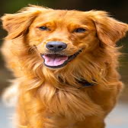

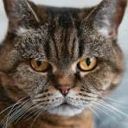

In [ ]:
from pathlib import Path
from PIL import Image

image1 = Path("dog1.jfif")
image2 = Path("cat2.jfif")
images = [image1,image2]
data = []
labels = []

for c,i in enumerate(images):
  with Image.open(i) as img:
    img = img.resize((128,128))
    img = img.convert('RGB')
    display(img)
    image_data = torch.from_numpy(np.array(img)/255.0).float().permute(2,0,1)
    data.append(image_data)
    labels.append(c)


In [ ]:
import time
model = Convolution(image_data , filters = 5 , kernel_size = 2 , pool_size = (2,2) , stride_pool = 2)
model.weights.requires_grad_(True)
model.linear_weights.requires_grad_(True)
model.biases.requires_grad_(True)
model.linear_biases.requires_grad_(True)

epochs = 5
rate = 0.001

for epoch in range(epochs):

  losses = 0
  t1 = time.time()

  for image,label in zip(data,labels):

    model.matrix_3D = image

    output = model.forward()

    loss = crossentropy(output , label)
    losses += loss.item()

    if model.weights.grad is not None:  # For each epoch , we have to calculate the gradient , update and   make the gradient zero too

      model.weights.grad.zero_()
      model.biases.grad.zero_()
      model.linear_weights.grad.zero_()
      model.linear_biases.grad.zero_()

    loss.backward()

    with torch.no_grad() :  # We don't want gradient descent step to be treated like a transformation by  the autograd engine

      model.weights -= rate * model.weights.grad
      model.biases -= rate * model.biases.grad
      model.linear_weights -= rate * model.linear_weights.grad
      model.linear_biases -= rate * model.linear_biases.grad

  print(f"Epochs : {epoch+1} {round(time.time()-t1,2)}s Loss : {losses/len(data)} ")

Epochs : 1 89.41s Loss : 0.8382770419120789 
Epochs : 2 87.4s Loss : 0.6973185241222382 
Epochs : 3 83.69s Loss : 0.5491338968276978 
Epochs : 4 84.45s Loss : 0.44379042088985443 
Epochs : 5 98.26s Loss : 0.3666248321533203 


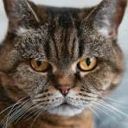

Logits  tensor([-0.5318,  0.6443])
Probabilities  tensor([0.2357, 0.7643])
Cat


In [ ]:
# Inference on Training Data

unseen = Path('cat2.jfif')
with Image.open(unseen) as img:
    img = img.resize((128,128))
    img = img.convert('RGB')
    display(img)
    image_data = torch.from_numpy(np.array(img)/255.0).float().permute(2,0,1)

with torch.no_grad() : # Gradient turned off during inference

  # We will not initialize the model otherwise weights will be lost

  model.matrix_3D = image_data

  output = model.forward()

  print("Logits ",output)

  output_prob = torch.softmax(output , dim = 0)

  print("Probabilities ",output_prob)

  pred_class = torch.argmax(output_prob).item()

  if pred_class == 1 :
    print("Cat")
  else:
    print("Dog")

  # Actual output is 1

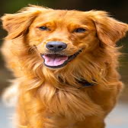

tensor([ 0.8385, -0.5632])
tensor([0.8025, 0.1975])
Dog


In [ ]:
# Inference on Training Data

unseen = Path('dog1.jfif')
with Image.open(unseen) as img:
    img = img.resize((128,128))
    img = img.convert('RGB')
    display(img)
    image_data = torch.from_numpy(np.array(img)/255.0).float().permute(2,0,1)

with torch.no_grad() : # Gradient turned off during inference

  # We will not initialize the model otherwise weights will be lost

  model.matrix_3D = image_data

  output = model.forward()

  print(output)

  output_prob = torch.softmax(output , dim = 0)

  print(output_prob)

  pred_class = torch.argmax(output_prob).item()

  if pred_class == 1 :
    print("Cat")
  else:
    print("Dog")

  # Actual output is 0

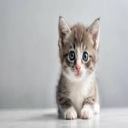

tensor([-0.1081,  0.2954])
tensor([0.4005, 0.5995])
Cat


In [ ]:
# Inference on Unknown Data

unseen = Path('cat1.jfif')
with Image.open(unseen) as img:
    img = img.resize((128,128))
    img = img.convert('RGB')
    display(img)
    image_data = torch.from_numpy(np.array(img)/255.0).float().permute(2,0,1)

with torch.no_grad() : # Gradient turned off during inference

  # We will not initialize the model otherwise weights will be lost

  model.matrix_3D = image_data

  output = model.forward()

  print(output)

  output_prob = torch.softmax(output , dim = 0)

  print(output_prob)

  pred_class = torch.argmax(output_prob).item()

  if pred_class == 1 :
    print("Cat")
  else:
    print("Dog")

  # Actual output is 1

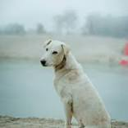

tensor([-0.0495,  0.2707])
tensor([0.4206, 0.5794])
Cat


In [ ]:
# Inference on Unknown Data

unseen = Path('dog3.jfif')
with Image.open(unseen) as img:
    img = img.resize((128,128))
    img = img.convert('RGB')
    display(img)
    image_data = torch.from_numpy(np.array(img)/255.0).float().permute(2,0,1)

with torch.no_grad() : # Gradient turned off during inference

  # We will not initialize the model otherwise weights will be lost

  model.matrix_3D = image_data

  output = model.forward()

  print(output)

  output_prob = torch.softmax(output , dim = 0)

  print(output_prob)

  pred_class = torch.argmax(output_prob).item()

  if pred_class == 1 :
    print("Cat")
  else:
    print("Dog")

  # Actual output is Dog

In [ ]:
!pip install torchviz graphviz

In [ ]:
# Visualizing the math and computational graph (Directed Acyclic Graph)

from torchviz import make_dot

# 1. Create a tiny fake 3D image matrix (1 channel, 5x5 pixels)
tiny_image = torch.randn(1, 5, 5)

# 2. Re-initialize your model structure with tiny dimensions
tiny_model = Convolution(tiny_image, filters=2, kernel_size=2, pool_size=(2,2), stride_pool=1)
tiny_model.weights.requires_grad_(True)
tiny_model.linear_weights.requires_grad_(True)
tiny_model.biases.requires_grad_(True)
tiny_model.linear_biases.requires_grad_(True)

# 3. Run a quick forward pass and loss calculation
tiny_output = tiny_model.forward()
tiny_loss = crossentropy(tiny_output, 1)

# 4. Render the graph (This will load in less than 2 seconds!)
dot = make_dot(tiny_loss, params={
    'weights': tiny_model.weights,
    'biases': tiny_model.biases,
    'linear_weights': tiny_model.linear_weights,
    'linear_biases': tiny_model.linear_biases
})
# Save the graph to a local file in Colab
dot.render("custom_nn_graph", format="png")

'custom_nn_graph.png'